<a href="https://colab.research.google.com/github/carterwyatt30/soc223/blob/main/Lecture_2_Step_3_NLP_and_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Traditional Machine Learning

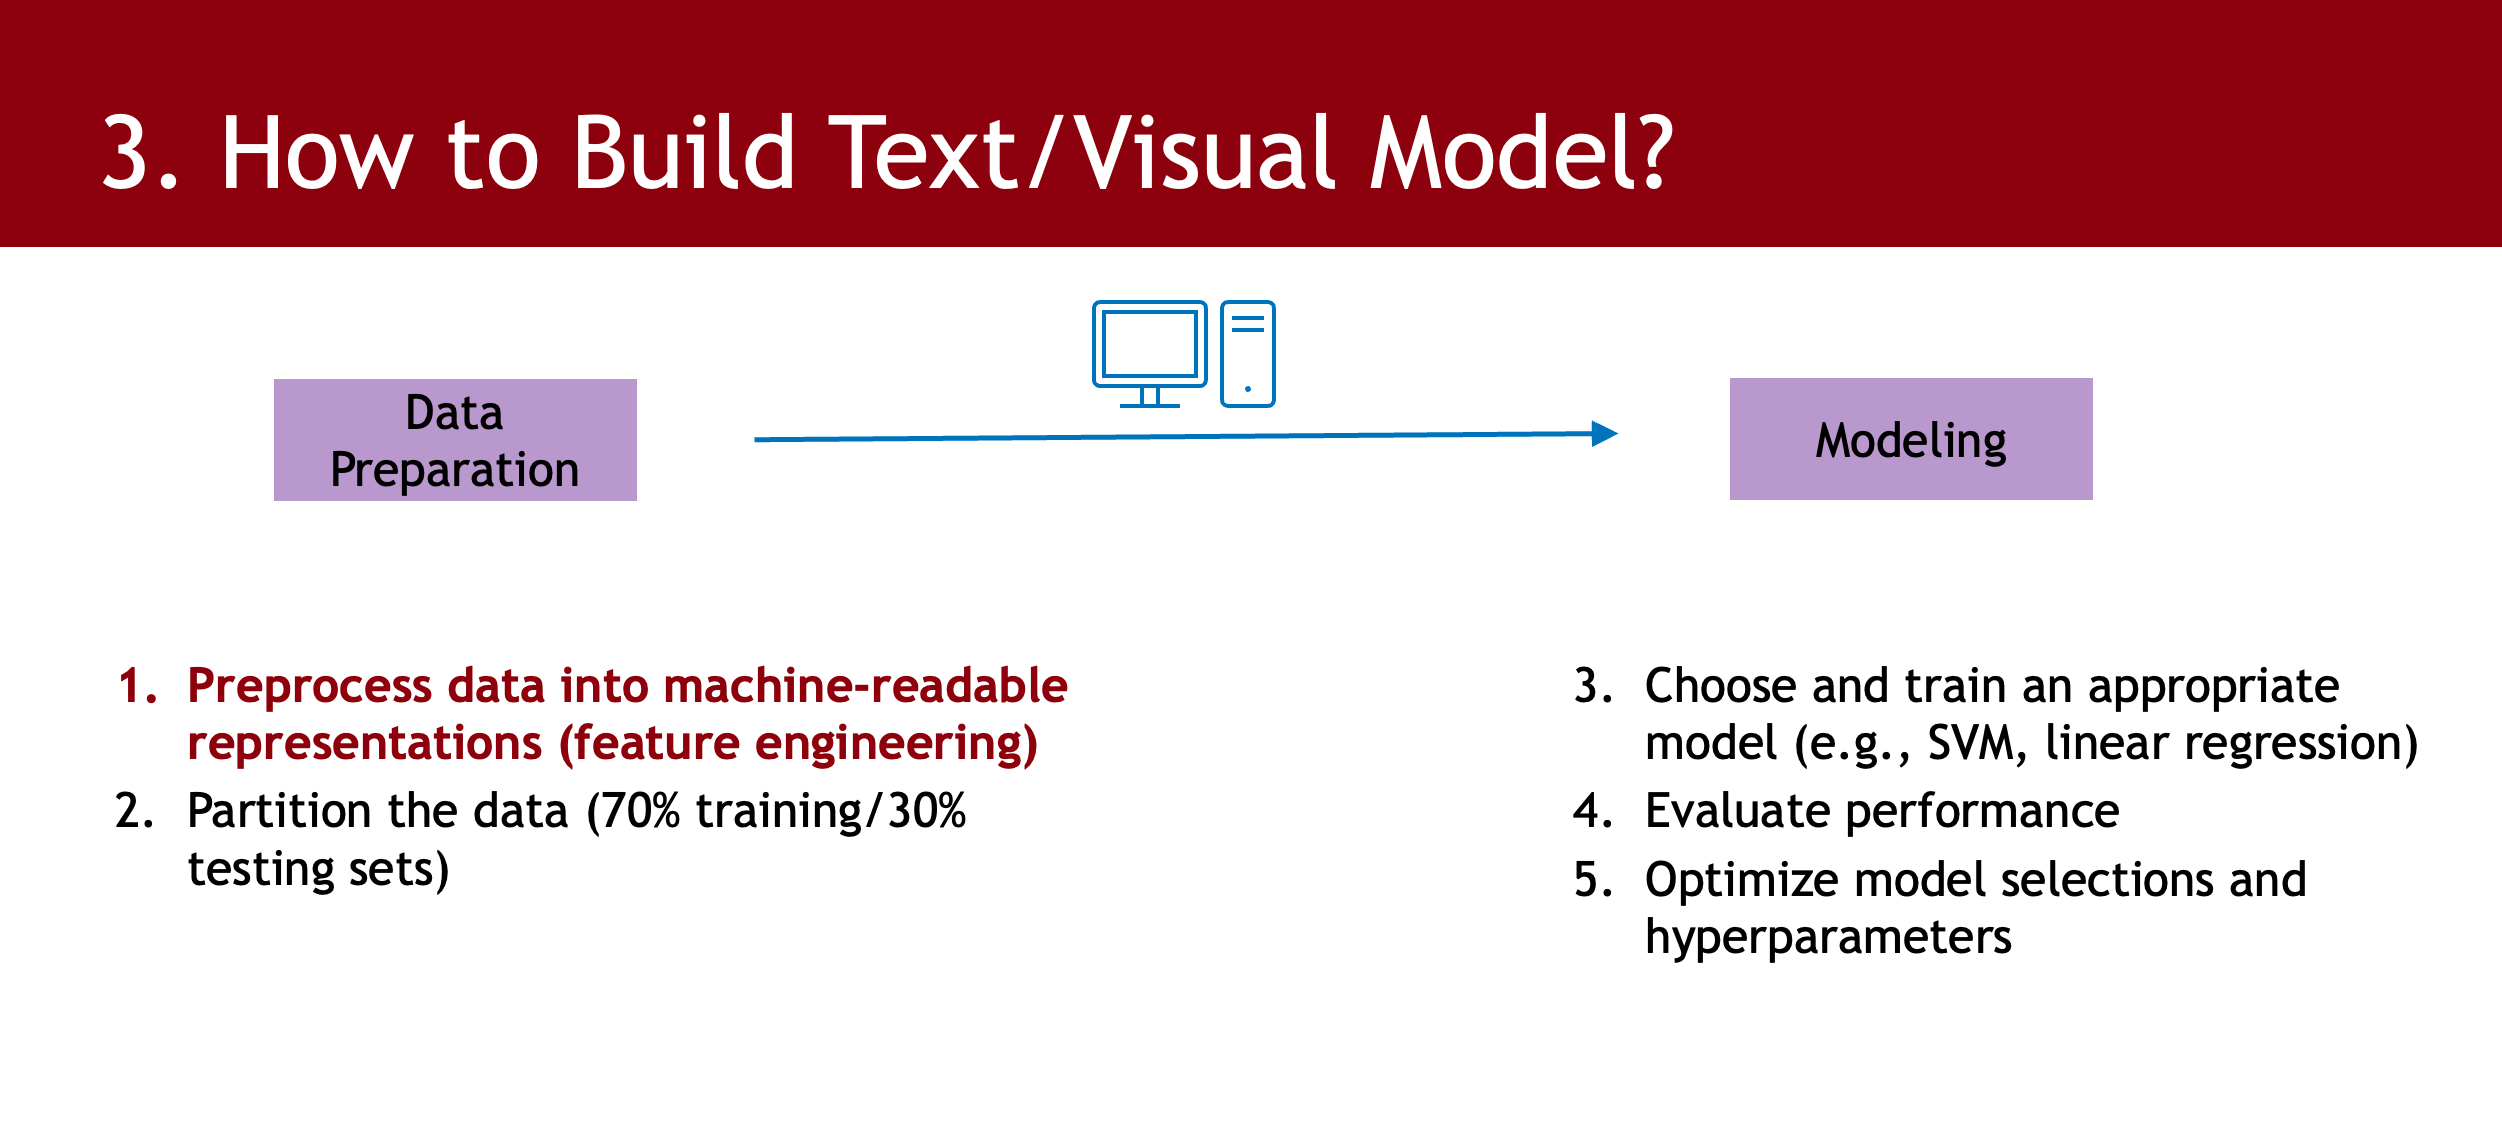

In [ ]:
# Block 0

import pandas as pd
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
from sklearn import datasets, metrics
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')
import warnings
warnings.simplefilter('ignore')

# Part 1: Conventional ML/NLP Approach

In [ ]:
# Block 1

data=pd.read_csv('https://raw.githubusercontent.com/xialongtc10/MGT4250/main/20_News.csv', encoding='ISO-8859-1')  #Change the file name to your data
print("dimension of data: {}".format(data.shape))
data.head()

In [ ]:
# Block 2

text_input = data[""]   # Change the column name to be your text variable name
y = data[""]   # Change the column name to be your target variable

In [ ]:
# Block 3

text_input[0]

In [ ]:
# Block 4

text_processed = re.sub("[^a-zA-Z]", " ", text_input[0])
text_processed

In [ ]:
# Block 5

eng_stopwords = set(stopwords.words("english"))
eng_stopwords

In [ ]:
# Block 6

text_processed = text_processed.lower().split()
text_processed

In [ ]:
# Block 7

# remove all the stopwords
clean_review=[]
for word in text_processed:
  if word not in eng_stopwords:
    clean_review.append(word)
review_processed=" ".join(clean_review)
review_processed

In [ ]:
# Block 8

# Putting everything together

cleaned_reviews = []
for i, review in enumerate(text_input):
    review = re.sub("[^a-zA-Z]", " ", review)
    review = review.lower().split()
    eng_stopwords = set(stopwords.words("english"))
    clean_review = []
    for word in review:
        if word not in eng_stopwords:
            clean_review.append(word)
    review_processed = " ".join(clean_review)
    cleaned_reviews.append(review_processed)

In [ ]:
# Block 9

ps = PorterStemmer()
vectorizer = CountVectorizer(max_features=100)
X = vectorizer.fit_transform(cleaned_reviews).toarray()

In [ ]:
# Block 10

print (text_input[0])
print ("*"*100)
print ((cleaned_reviews[0]))
print ("*"*100)
print (X[0])

In [ ]:
# Block 11

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)
print (X_train.shape, X_test.shape)

In [ ]:
# Block 12

model = RandomForestClassifier()   # Change here to select different models
model.fit(X_train, y_train)

In [ ]:
# Block 13

print("Training set score: {:.3f}".format(model.score(X_train, y_train)))
print("Test set score: {:.3f}".format(model.score(X_test, y_test)))

In [ ]:
# Block 14

predicted = model.predict(X_test)
report = metrics.classification_report(y_test,predicted)
print (report)

# Part 2: Deep Learning Approach
### Note: Please enable GPU

In [ ]:
# Block 15

import numpy as np
import tensorflow as tf
import pandas as pd
from sklearn.model_selection import train_test_split
import os
import pathlib
from sklearn import datasets, metrics
from keras.models import Sequential
from keras.layers import Dense
import matplotlib.pyplot as plt
import numpy

In [ ]:
# Block 16

tf.test.gpu_device_name()

In [ ]:
# Block 17

data=pd.read_csv('https://raw.githubusercontent.com/xialongtc10/MGT4250/main/20_News.csv', encoding='ISO-8859-1')  #Change the file name to your data
print("dimension of data: {}".format(data.shape))
data.head()

In [ ]:
# Block 18

text_input = data["message"]   # Change the column name to be your text variable name
y = data["topic"]   # Change the column name to be your target variable
text_input[0]

In [ ]:
# Block 19

vectorizer = tf.keras.layers.TextVectorization(max_tokens=20000, output_sequence_length=200)
text_ds = tf.data.Dataset.from_tensor_slices(text_input).batch(128)
vectorizer.adapt(text_ds)
voc = vectorizer.get_vocabulary()
word_index = dict(zip(voc, range(len(voc))))


In [ ]:
# Block 20

text_input = vectorizer(np.array([[s] for s in text_input])).numpy()
text_input[0]

In [ ]:
# Block 21

print (y[0])

In [ ]:
# Block 22

y = tf.keras.utils.to_categorical(y, num_classes=20)

In [ ]:
# Block 23

print (y[0])

In [ ]:
# Block 24

X_train, X_test, y_train, y_test = train_test_split(text_input, y, test_size = 0.3)
print (X_train.shape, X_test.shape)

In [ ]:
# Block 25

data_path = tf.keras.utils.get_file(
    "glove6b",
    "http://nlp.stanford.edu/data/glove.6B.zip",
    extract=True,)

path_to_glove_file = pathlib.Path(data_path).parent / "glove6b/glove.6B.100d.txt"

embeddings_index = {}
with open(path_to_glove_file) as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs

print("Found %s word vectors." % len(embeddings_index))
for word, vector in embeddings_index.items():
  print (word, vector)
  break

In [ ]:
# Block 26

num_tokens = len(voc) + 2
embedding_dim = 100
hits = 0
misses = 0

embedding_matrix = np.random.rand(num_tokens, embedding_dim)
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        misses += 1
print("Converted %d words (%d misses)" % (hits, misses))

In [ ]:
# Block 27

embedding_layer = tf.keras.layers.Embedding(
    num_tokens,
    embedding_dim,
    embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
    trainable=True,
)

int_sequences_input = tf.keras.Input(shape=(None,), dtype="int64")
embedded_sequences = embedding_layer(int_sequences_input)
x = tf.keras.layers.Conv1D(128, 5, activation="relu")(embedded_sequences)
x = tf.keras.layers.MaxPooling1D(5)(x)
x = tf.keras.layers.Conv1D(128, 5, activation="relu")(x)
x = tf.keras.layers.GlobalMaxPooling1D()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)
preds = tf.keras.layers.Dense(20, activation="softmax")(x)   # You will need to adjust
model = tf.keras.Model(int_sequences_input, preds)
model.summary()

In [ ]:
# Block 28

model.compile(
    loss="categorical_crossentropy", optimizer="rmsprop", metrics=["acc"]
)
history0 = model.fit(X_train, y_train, batch_size=64, epochs=30, validation_split=0.3)

In [ ]:
# Block 29

predicted = np.argmax(model.predict(X_test),axis=1)
expected = np.argmax(y_test,axis=1)
report = metrics.classification_report(expected,predicted)
print (report)

In [ ]:
# To do: please report your performance for a side-by-side comparison

# Report the performance of model architecture 1:
# Accuracy:
# Precision:
# Recall:
# F1/F-measure:

# Report the performance of model architecture 2:
# Accuracy:
# Precision:
# Recall:
# F1/F-measure: